<a href="https://colab.research.google.com/github/HaruWatXXD67/quant-projects/blob/main/bayesian_gibbs_truncated_multivariate_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
np.random.seed(1000000)

In [2]:
def sample_truncated_normal(mean, std, lower):
    """Samples from a univariate truncated normal distribution [lower, inf)."""
    if std <= 0:
        return mean
    a = (lower - mean) / std
    return truncnorm.rvs(a, np.inf, loc=mean, scale=std)

In [3]:
def gibbs_truncated_normal(mu, sigma, num_samples=5000, burn_in=1000, lower_bound=0.0):
    """
    Implements Gibbs sampling for a Truncated Multivariate Normal Distribution.
    Truncation is applied such that all elements >= lower_bound.
    """
    d = len(mu)
    samples = np.zeros((num_samples, d))

    current_state = np.maximum(mu, lower_bound + 0.1)

    cond_means_factor = []
    cond_stds = []

    for i in range(d):
        not_i = [j for j in range(d) if j != i]

        sigma_ii = sigma[i, i]
        sigma_i_noti = sigma[i, not_i]
        sigma_noti_noti = sigma[np.ix_(not_i, not_i)]
        sigma_noti_i = sigma[not_i, i]

        inv_sigma_noti_noti = np.linalg.inv(sigma_noti_noti)

        factor = sigma_i_noti @ inv_sigma_noti_noti
        cond_means_factor.append((not_i, factor))

        cond_var = sigma_ii - factor @ sigma_noti_i
        cond_stds.append(np.sqrt(max(cond_var, 1e-9)))

In [5]:
def gibbs_truncated_normal(mu, sigma, num_samples=5000, burn_in=1000, lower_bound=0.0):
    """
    Implements Gibbs sampling for a Truncated Multivariate Normal Distribution.
    Truncation is applied such that all elements >= lower_bound.
    """
    d = len(mu)
    samples = np.zeros((num_samples, d))

    current_state = np.maximum(mu, lower_bound + 0.1)

    cond_means_factor = []
    cond_stds = []

    for i in range(d):
        not_i = [j for j in range(d) if j != i]

        sigma_ii = sigma[i, i]
        sigma_i_noti = sigma[i, not_i]
        sigma_noti_noti = sigma[np.ix_(not_i, not_i)]
        sigma_noti_i = sigma[not_i, i]

        inv_sigma_noti_noti = np.linalg.inv(sigma_noti_noti)

        factor = sigma_i_noti @ inv_sigma_noti_noti
        cond_means_factor.append((not_i, factor))

        cond_var = sigma_ii - factor @ sigma_noti_i
        cond_stds.append(np.sqrt(max(cond_var, 1e-9)))

    total_iterations = num_samples + burn_in
    sample_idx = 0

    for step in range(total_iterations):
        for i in range(d):
            not_i, factor = cond_means_factor[i]

            mu_i = mu[i]
            mu_noti = mu[not_i]
            x_noti = current_state[not_i]

            cond_mean = mu_i + factor @ (x_noti - mu_noti)
            cond_std = cond_stds[i]

            current_state[i] = sample_truncated_normal(cond_mean, cond_std, lower_bound)

        if step >= burn_in:
            samples[sample_idx] = current_state
            sample_idx += 1

    return samples


In [6]:
d = 5
Sigma = np.zeros((d, d))

for i in range(d):
    for j in range(d):
        Sigma[i, j] = 0.9 ** abs(i - j)

mu_1 = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
mu_2 = np.array([4.0, 4.0, 4.0, 4.0, 4.0])

print("Covariance Matrix (Sigma):\n", Sigma)

Covariance Matrix (Sigma):
 [[1.     0.9    0.81   0.729  0.6561]
 [0.9    1.     0.9    0.81   0.729 ]
 [0.81   0.9    1.     0.9    0.81  ]
 [0.729  0.81   0.9    1.     0.9   ]
 [0.6561 0.729  0.81   0.9    1.    ]]


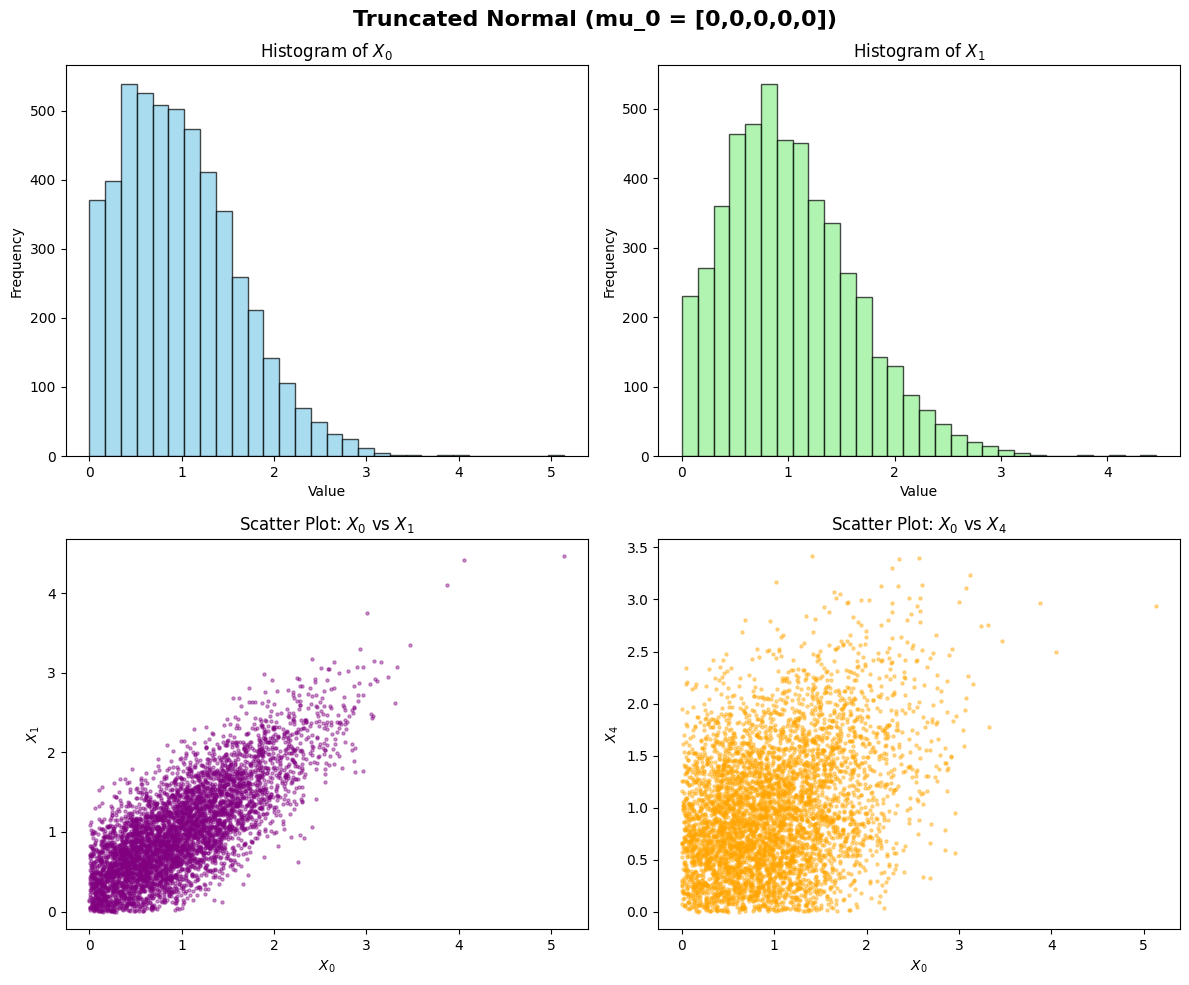

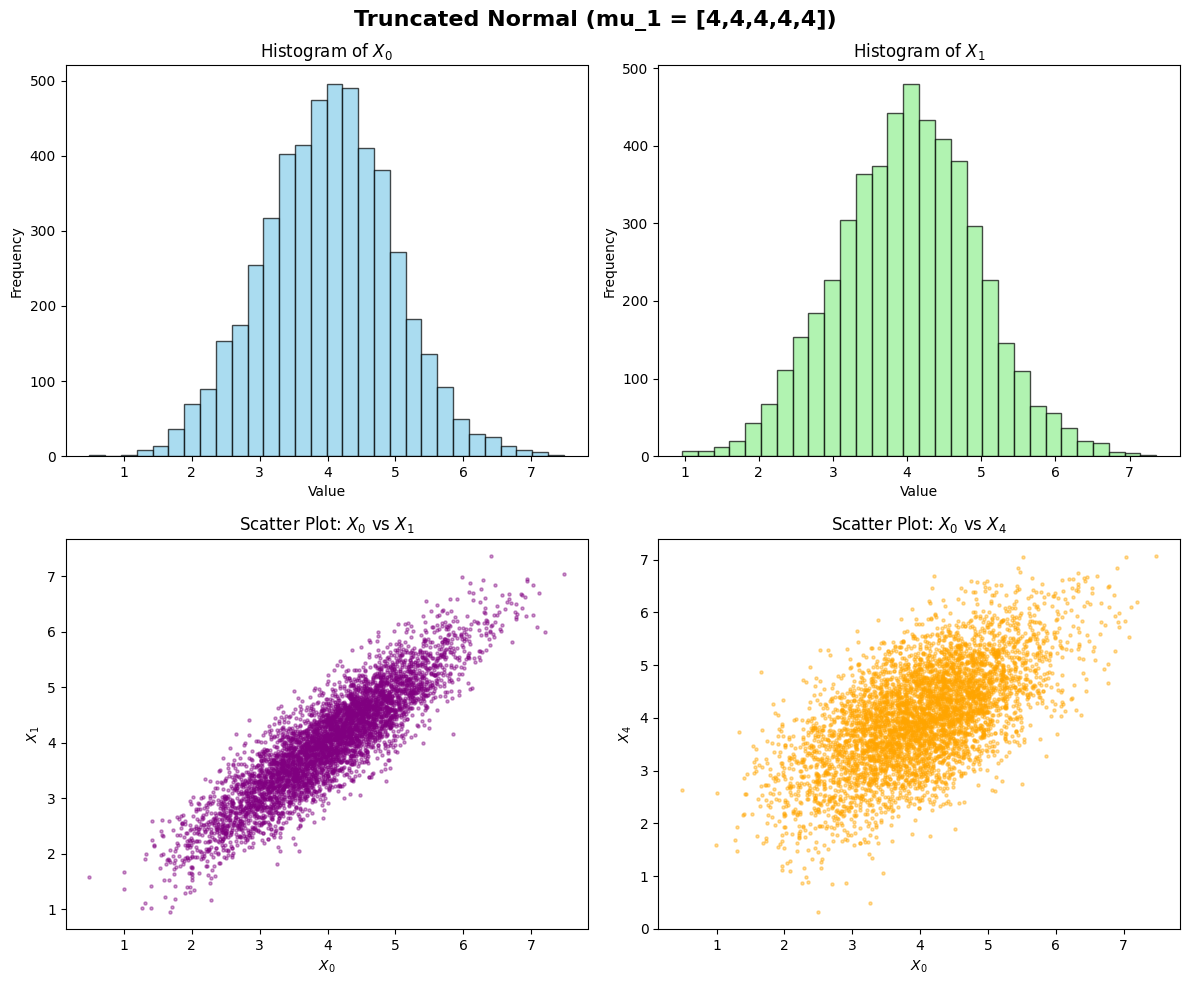

In [9]:
def plot_results(samples, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 1. Histogram of Dimension 1 (X0)
    axes[0, 0].hist(samples[:, 0], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title("Histogram of $X_0$")
    axes[0, 0].set_xlabel("Value")
    axes[0, 0].set_ylabel("Frequency")

    # 2. Histogram of Dimension 2 (X1)
    axes[0, 1].hist(samples[:, 1], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title("Histogram of $X_1$")
    axes[0, 1].set_xlabel("Value")
    axes[0, 1].set_ylabel("Frequency")

    # 3. Scatter plot between X0 and X1
    axes[1, 0].scatter(samples[:, 0], samples[:, 1], alpha=0.4, color='purple', s=5)
    axes[1, 0].set_title("Scatter Plot: $X_0$ vs $X_1$")
    axes[1, 0].set_xlabel("$X_0$")
    axes[1, 0].set_ylabel("$X_1$")

    # 4. Scatter plot between X0 and X4
    axes[1, 1].scatter(samples[:, 0], samples[:, 4], alpha=0.4, color='orange', s=5)
    axes[1, 1].set_title("Scatter Plot: $X_0$ vs $X_4$")
    axes[1, 1].set_xlabel("$X_0$")
    axes[1, 1].set_ylabel("$X_4$")

    plt.tight_layout()
    plt.show()

# Generate samples for case 1 and case 2
samples_case1 = gibbs_truncated_normal(mu_1, Sigma)
samples_case2 = gibbs_truncated_normal(mu_2, Sigma)

plot_results(samples_case1, "Truncated Normal (mu_0 = [0,0,0,0,0])")
plot_results(samples_case2, "Truncated Normal (mu_1 = [4,4,4,4,4])")